In [13]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install matplotlib

In [15]:
pip install scipy

In [16]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install seaborn

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing


In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/overstimulation-behavior-and-lifestyle-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\miadul\overstimulation-behavior-and-lifestyle-dataset\versions\1


In [20]:
import pandas as pd
import os

# Try multiple possible locations
possible_paths = [
    '/kaggle/input/overstimulation-behavior-and-lifestyle-dataset/overstimulation_dataset.csv',
    'overstimulation_dataset.csv',
    '../input/overstimulation_dataset.csv',
    'data/overstimulation_dataset.csv'
]

for path in possible_paths:
    try:
        df = pd.read_csv(path)
        print(f"Successfully loaded from: {path}")
        break
    except FileNotFoundError:
        continue
else:
    print("File not found in any common locations. Please:")
    print("1. Check the file exists")
    print("2. Verify the path is correct")
    print(f"Current working directory: {os.getcwd()}")
    print(f"Files here: {os.listdir()}")

Successfully loaded from: overstimulation_dataset.csv


In [21]:
# Imports and configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # for matplotlib as per requirements
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # if only plt is used
%matplotlib inline

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance

# Set seaborn style for plots
sns.set(style="whitegrid")

# Display basic pandas config
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv('overstimulation_dataset.csv')

In [24]:
df.head(5)

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated
0,56,7.767825,4.908517,2,0,8,11,2.054411,4,0,6,8,3,1,1,8,1,2,8.746524,0
1,46,4.270068,8.413936,9,4,4,10,2.513216,3,1,4,4,2,1,5,5,2,4,8.508448,1
2,32,6.676144,1.688213,5,2,8,12,2.123108,2,1,4,3,2,1,8,7,2,4,5.701592,0
3,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0
4,38,3.748138,9.899260,5,0,5,4,0.093407,4,0,9,4,0,1,2,9,5,3,2.286433,1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2000 non-null   int64  
 1   Sleep_Hours          2000 non-null   float64
 2   Screen_Time          2000 non-null   float64
 3   Stress_Level         2000 non-null   int64  
 4   Noise_Exposure       2000 non-null   int64  
 5   Social_Interaction   2000 non-null   int64  
 6   Work_Hours           2000 non-null   int64  
 7   Exercise_Hours       2000 non-null   float64
 8   Caffeine_Intake      2000 non-null   int64  
 9   Multitasking_Habit   2000 non-null   int64  
 10  Anxiety_Score        2000 non-null   int64  
 11  Depression_Score     2000 non-null   int64  
 12  Sensory_Sensitivity  2000 non-null   int64  
 13  Meditation_Habit     2000 non-null   int64  
 14  Overthinking_Score   2000 non-null   int64  
 15  Irritability_Score   2000 non-null   i

In [32]:
print('Missing values in each column:')
print(df.isnull().sum())

print('\nData types of the columns:')
print(df.dtypes)

# In case any data conversion is required, it can be performed here (e.g., converting columns to appropriate numeric types)
for col in df.columns:
    if df[col].dtype == 'O':
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception as e:
            print(f"Column {col} could not be converted automatically: {e}")

# Verifying the conversion
print('\nData types after potential conversion:')
print(df.dtypes)

Missing values in each column:
Age                    0
Sleep_Hours            0
Screen_Time            0
Stress_Level           0
Noise_Exposure         0
Social_Interaction     0
Work_Hours             0
Exercise_Hours         0
Caffeine_Intake        0
Multitasking_Habit     0
Anxiety_Score          0
Depression_Score       0
Sensory_Sensitivity    0
Meditation_Habit       0
Overthinking_Score     0
Irritability_Score     0
Headache_Frequency     0
Sleep_Quality          0
Tech_Usage_Hours       0
Overstimulated         0
dtype: int64

Data types of the columns:
Age                      int64
Sleep_Hours            float64
Screen_Time            float64
Stress_Level             int64
Noise_Exposure           int64
Social_Interaction       int64
Work_Hours               int64
Exercise_Hours         float64
Caffeine_Intake          int64
Multitasking_Habit       int64
Anxiety_Score            int64
Depression_Score         int64
Sensory_Sensitivity      int64
Meditation_Habit         

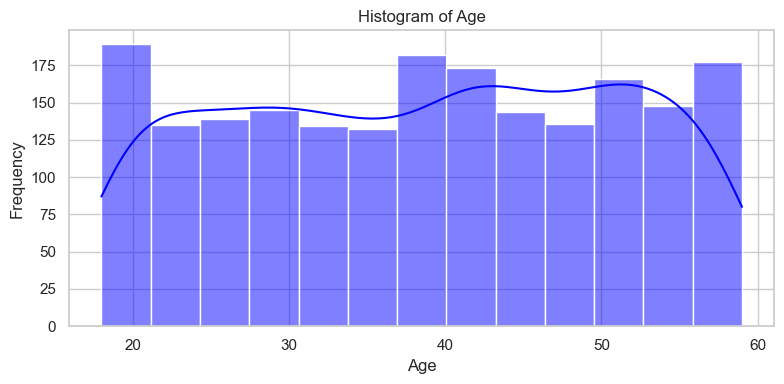

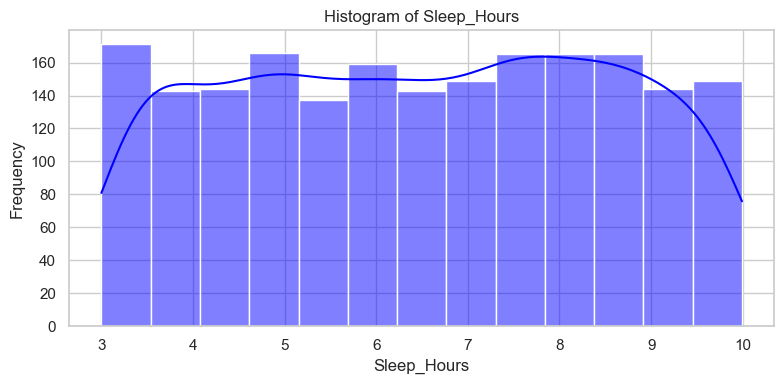

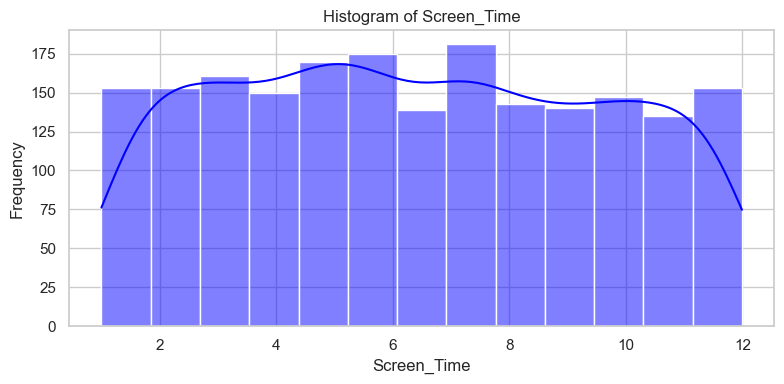

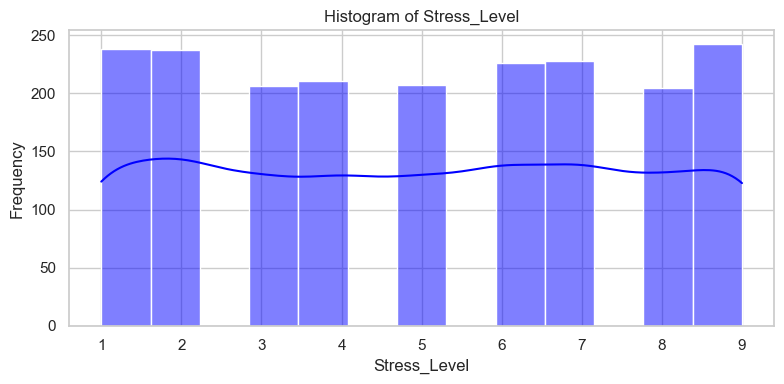

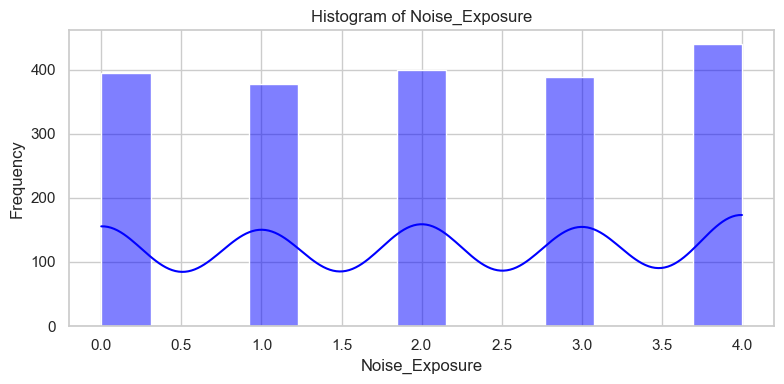

...

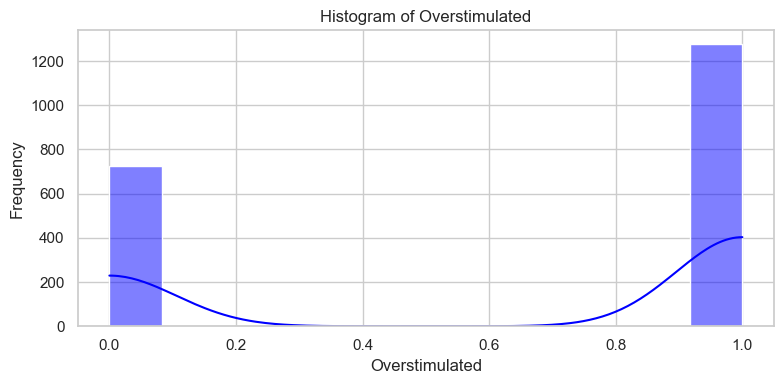

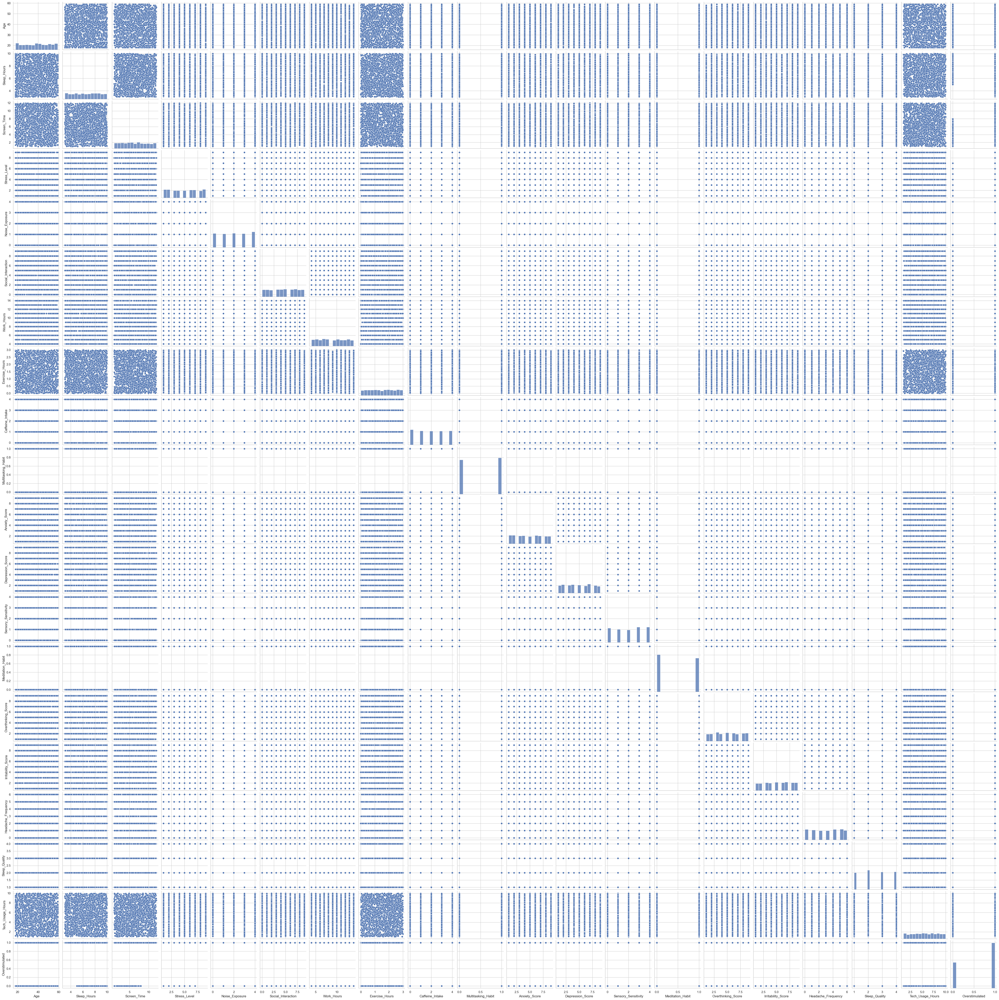

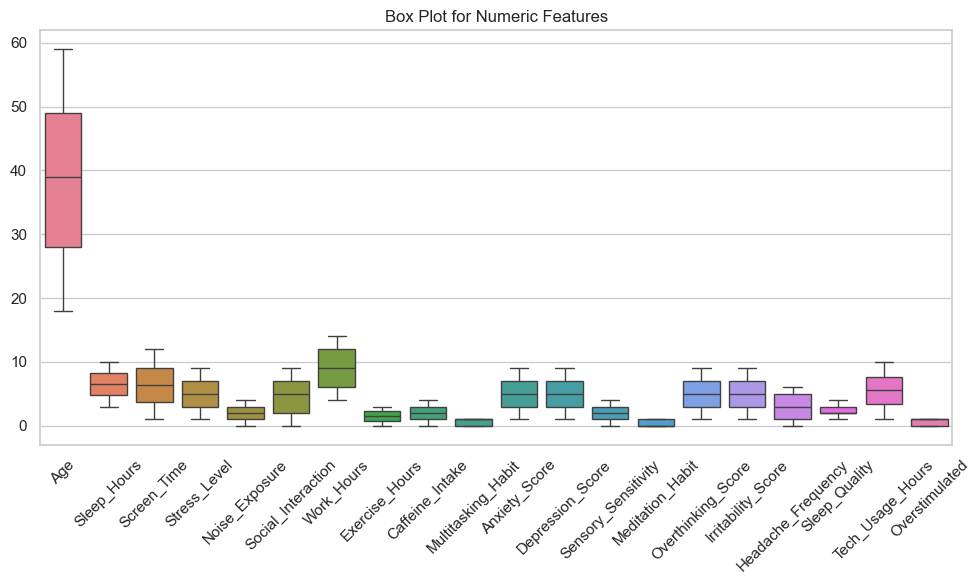

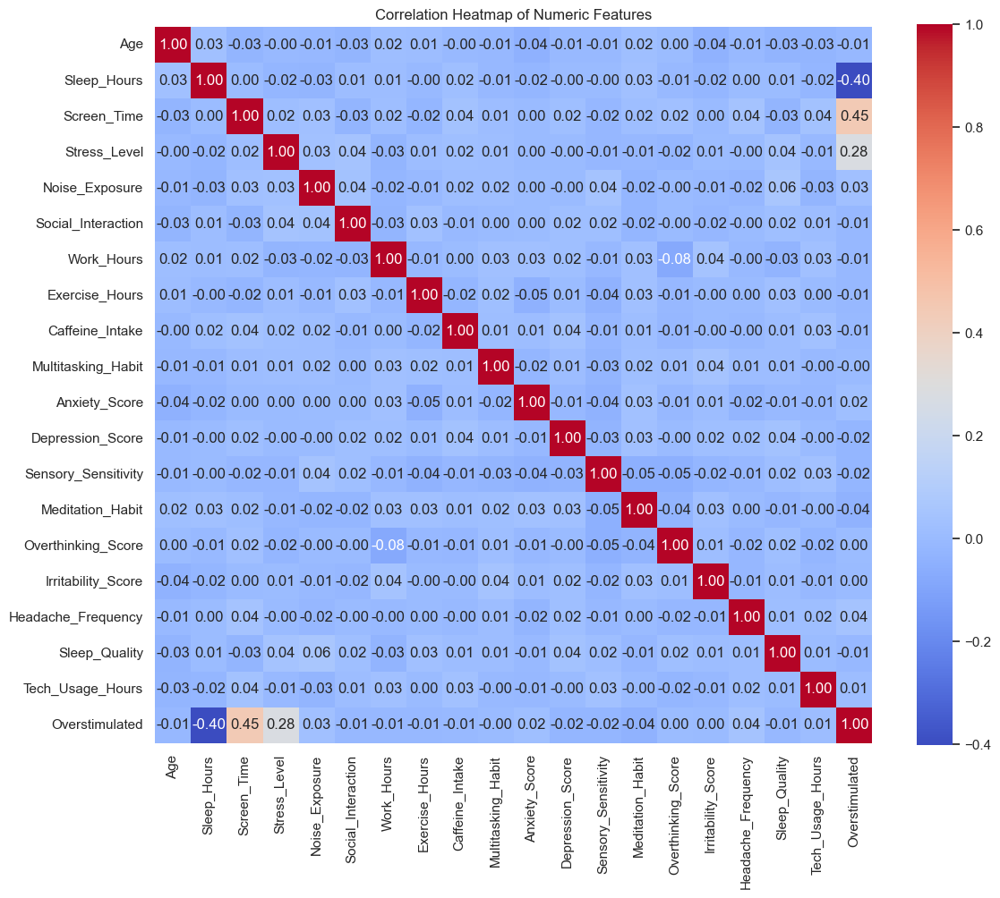

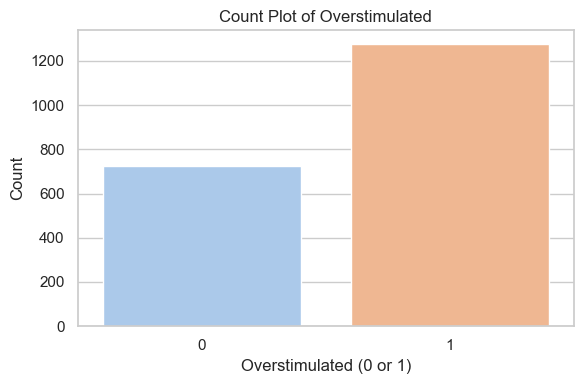

In [33]:
# Visualization: Histograms for various numerical columns
num_cols = [col for col in df.columns if df[col].dtype in [np.int64, np.float64]]

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, color='blue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Visualization: Pair Plot to examine relationships between several key features
sns.pairplot(df[num_cols])
plt.show()

# Visualization: Box Plot for detecting outliers in selected features
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[num_cols])
plt.title('Box Plot for Numeric Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# If there are four or more numeric columns, create a correlation heatmap
if len(num_cols) >= 4:
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()

# Visualization: Count Plot (Pie Chart style) for the target variable 'Overstimulated'
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Overstimulated'], palette='pastel')
plt.title('Count Plot of Overstimulated')
plt.xlabel('Overstimulated (0 or 1)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")

print("Path to dataset files:", path)

100%|██████████| 89.0M/89.0M [00:22<00:00, 4.14MB/s]

Extracting files...


Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\himanshupoddar\zomato-bangalore-restaurants\versions\1


In [36]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt # plotting
import numpy as np # linear algebra
import os # accessing directory structure
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [38]:
import os
print("Current working directory:", os.getcwd())
print("Files/folders here:", os.listdir())

Current working directory: c:\Users\PC\Documents\Mercy Python folder
Files/folders here: ["'songs  .py", '.vscode', 'ADHD.ipynb', 'bank-additional-full.csv', 'Bank.csv', 'bk.ipynb', 'Celsius_Tmperature.py', 'contacts py', 'contacts py.txt', 'contact_list.py', 'Copy_of_logistic_regression.ipynb', 'data.py', 'EDA.ipynb', 'hello_world.py', 'import pandas as pd.py', 'logistic_regression.ipynb', 'Mercy Python folder.code-workspace', 'overstimulation_dataset.csv', 'pop.ipynb', 'projectijpy.ipynb', 'responses.csv', 'songs_py', 'Untitled-1.ipynb', 'Untitled.ipynb', 'with.py', 'world_population.csv']


In [41]:
import os

# Try multiple common locations
possible_paths = [
    '../input',
    'input',
    '/kaggle/input',
    './'
]

for path in possible_paths:
    try:
        print(f"Contents of {path}:", os.listdir(path))
        break
    except FileNotFoundError:
        print(f"Not found: {path}")

Not found: ../input
Not found: input
Not found: /kaggle/input
Contents of ./: ["'songs  .py", '.vscode', 'ADHD.ipynb', 'bank-additional-full.csv', 'Bank.csv', 'bk.ipynb', 'Celsius_Tmperature.py', 'contacts py', 'contacts py.txt', 'contact_list.py', 'Copy_of_logistic_regression.ipynb', 'data.py', 'EDA.ipynb', 'hello_world.py', 'import pandas as pd.py', 'logistic_regression.ipynb', 'Mercy Python folder.code-workspace', 'overstimulation_dataset.csv', 'pop.ipynb', 'projectijpy.ipynb', 'responses.csv', 'songs_py', 'Untitled-1.ipynb', 'Untitled.ipynb', 'with.py', 'world_population.csv']


In [46]:
possible_paths = [
    'zomato.csv',                   # Current folder
    '../input/zomato.csv',          # Common alternative
    '/kaggle/input/zomato.csv',     # Kaggle path
    'data/zomato.csv'               # Common data folder
]

for path in possible_paths:
    try:
        df1 = pd.read_csv(path)
        print(f"Successfully loaded from: {path}")
        break
    except FileNotFoundError:
        continue
else:
    print("File not found. Please:")
    print(f"1. Check if 'zomato.csv' exists in: {os.getcwd()}")
    print(f"2. Current files: {os.listdir()}")
    print("3. Move the file to your project folder or update the path")

File not found. Please:
1. Check if 'zomato.csv' exists in: c:\Users\PC\Documents\Mercy Python folder
2. Current files: ["'songs  .py", '.vscode', 'ADHD.ipynb', 'bank-additional-full.csv', 'Bank.csv', 'bk.ipynb', 'Celsius_Tmperature.py', 'contacts py', 'contacts py.txt', 'contact_list.py', 'Copy_of_logistic_regression.ipynb', 'data.py', 'EDA.ipynb', 'hello_world.py', 'import pandas as pd.py', 'logistic_regression.ipynb', 'Mercy Python folder.code-workspace', 'overstimulation_dataset.csv', 'pop.ipynb', 'projectijpy.ipynb', 'responses.csv', 'songs_py', 'Untitled-1.ipynb', 'Untitled.ipynb', 'with.py', 'world_population.csv']
3. Move the file to your project folder or update the path


In [47]:
df.head(5)

,Age,Sleep_Hours,Screen_Time,Stress_Level,Noise_Exposure,Social_Interaction,Work_Hours,Exercise_Hours,Caffeine_Intake,Multitasking_Habit,Anxiety_Score,Depression_Score,Sensory_Sensitivity,Meditation_Habit,Overthinking_Score,Irritability_Score,Headache_Frequency,Sleep_Quality,Tech_Usage_Hours,Overstimulated
0,56,7.767825,4.908517,2,0,8,11,2.054411,4,0,6,8,3,1,1,8,1,2,8.746524,0
1,46,4.270068,8.413936,9,4,4,10,2.513216,3,1,4,4,2,1,5,5,2,4,8.508448,1
2,32,6.676144,1.688213,5,2,8,12,2.123108,2,1,4,3,2,1,8,7,2,4,5.701592,0
3,25,7.963324,3.315576,7,2,8,13,1.217663,3,1,3,4,0,1,4,4,2,1,9.131087,0
4,38,3.748138,9.899260,5,0,5,4,0.093407,4,0,9,4,0,1,2,9,5,3,2.286433,1


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  2000 non-null   int64  
 1   Sleep_Hours          2000 non-null   float64
 2   Screen_Time          2000 non-null   float64
 3   Stress_Level         2000 non-null   int64  
 4   Noise_Exposure       2000 non-null   int64  
 5   Social_Interaction   2000 non-null   int64  
 6   Work_Hours           2000 non-null   int64  
 7   Exercise_Hours       2000 non-null   float64
 8   Caffeine_Intake      2000 non-null   int64  
 9   Multitasking_Habit   2000 non-null   int64  
 10  Anxiety_Score        2000 non-null   int64  
 11  Depression_Score     2000 non-null   int64  
 12  Sensory_Sensitivity  2000 non-null   int64  
 13  Meditation_Habit     2000 non-null   int64  
 14  Overthinking_Score   2000 non-null   int64  
 15  Irritability_Score   2000 non-null   i

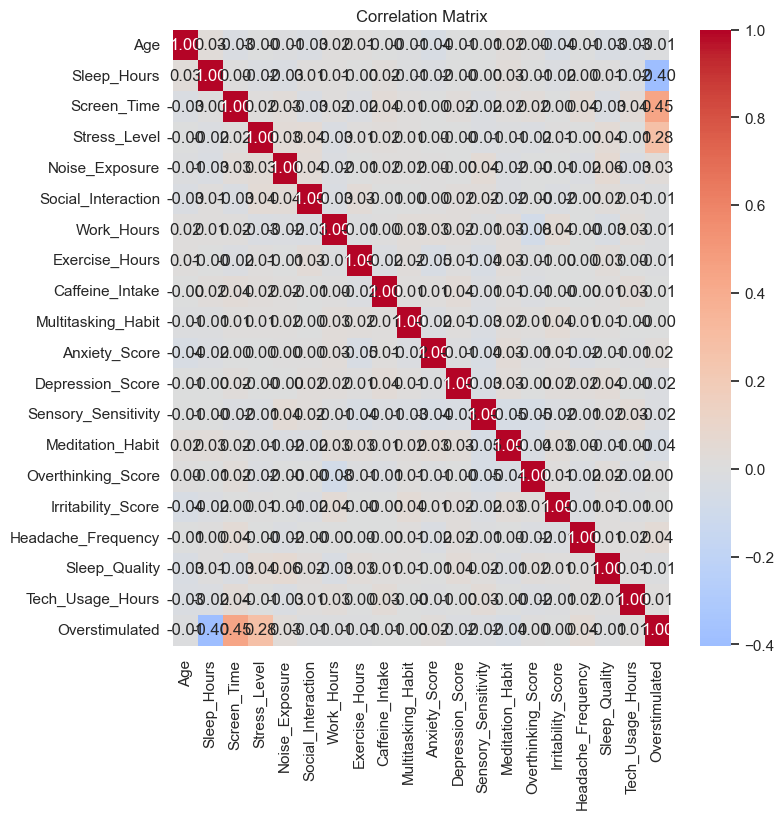

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
corr = df.corr()

# Create heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

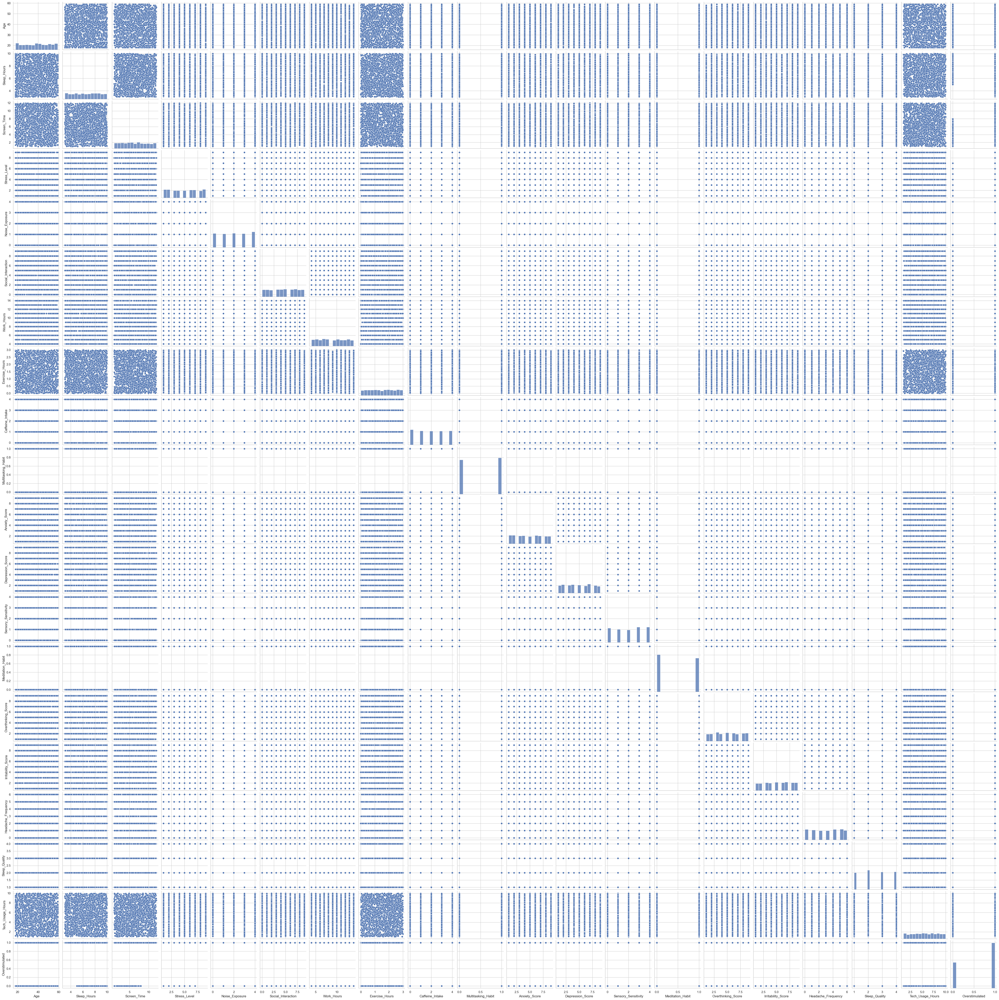

In [58]:
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Create pairplot
sns.pairplot(numeric_df)
plt.show()

Fitted Parameters:
Alpha1 (β₀): 10.981
Alpha2 (β₁): -6.985
Alpha3 (β₂): 0.000
Lambda: 1.417


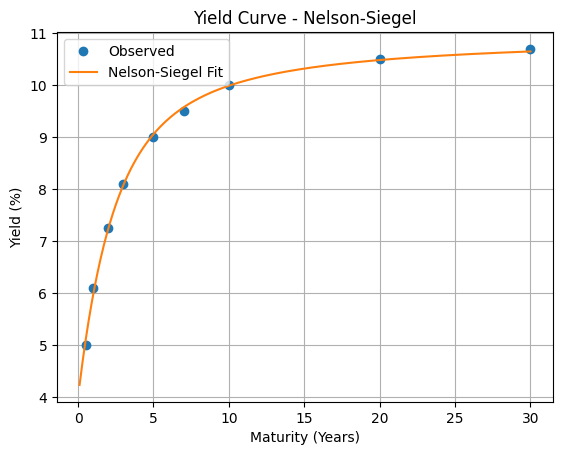

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Sample yield data
maturities = np.array([0.5, 1, 2, 3, 5, 7, 10, 20, 30])
yields = np.array([5.00, 6.10, 7.25, 8.10, 9.00, 9.50, 10.00, 10.50, 10.70])

def nelson_siegel(tau, beta0, beta1, beta2, lambd):
    term1 = beta0
    term2 = beta1 * (1 - np.exp(-tau / lambd)) / (tau / lambd)
    term3 = beta2 * ((1 - np.exp(-tau / lambd)) / (tau / lambd) - np.exp(-tau / lambd))
    return term1 + term2 + term3

def objective(params):
    beta0, beta1, beta2, lambd = params
    predicted = nelson_siegel(maturities, beta0, beta1, beta2, lambd)
    return np.sum((yields - predicted)**2)

initial_guess = [9, -3, 3, 1]
result = minimize(objective, initial_guess, method='L-BFGS-B')
beta0, beta1, beta2, lambd = result.x

print(f"Fitted Parameters:\nAlpha1 (β₀): {beta0:.3f}\nAlpha2 (β₁): {beta1:.3f}\nAlpha3 (β₂): {beta2:.3f}\nLambda: {lambd:.3f}")

# Plot
tau_range = np.linspace(0.1, 30, 300)
fitted_yield = nelson_siegel(tau_range, *result.x)

plt.plot(maturities, yields, 'o', label='Observed')
plt.plot(tau_range, fitted_yield, label='Nelson-Siegel Fit')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curve - Nelson-Siegel")
plt.legend()
plt.grid(True)
plt.show()


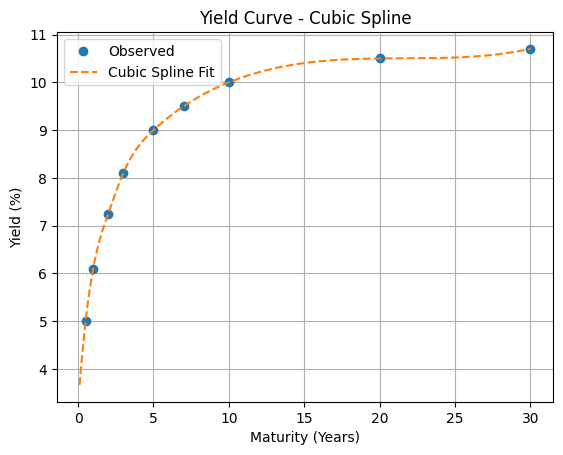

In [2]:
from scipy.interpolate import CubicSpline

cs = CubicSpline(maturities, yields)
spline_yield = cs(tau_range)

plt.plot(maturities, yields, 'o', label='Observed')
plt.plot(tau_range, spline_yield, label='Cubic Spline Fit', linestyle='--')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curve - Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()


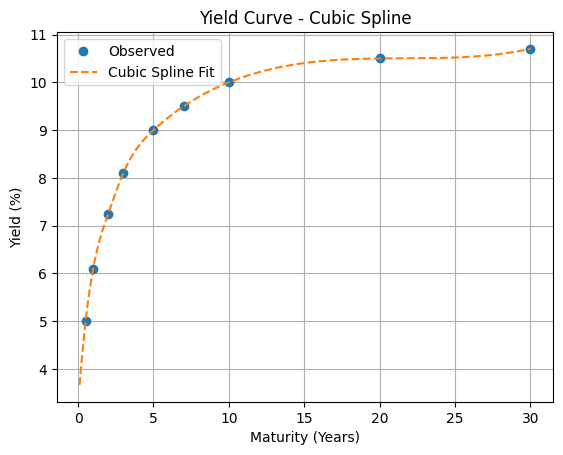

In [4]:
from scipy.interpolate import CubicSpline

cs = CubicSpline(maturities, yields)
spline_yield = cs(tau_range)

plt.plot(maturities, yields, 'o', label='Observed')
plt.plot(tau_range, spline_yield, label='Cubic Spline Fit', linestyle='--')
plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (%)")
plt.title("Yield Curve - Cubic Spline")
plt.legend()
plt.grid(True)
plt.show()
